<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day12-alphafold-and-generative-models-in-code.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Day 12 — AlphaFold and generative models of protein structure, in code {.unnumbered}

Three parts, following the book page:

1. **From contacts to distances.** Real contact maps are not random: only
   a fraction of all possible local patterns ever occur. This is what the
   contact predictors of the late 2010s learned to exploit.
2. **AlphaFold2 in practice.** Fetch AlphaFold DB models with their
   confidence scores (pLDDT, PAE), compare a model with the crystal
   structure, see what low confidence means for a partly disordered
   protein (p53), and predict a structure from a single sequence with
   ESMFold.
3. **Generative models.** The forward noising process of a diffusion
   model, and a small diffusion model that turns pure noise into data.
   AlphaFold3 and RFdiffusion use the same idea on atom coordinates.

Everything runs on a CPU in a few minutes. Structures and models are
fetched live from the RCSB PDB, the AlphaFold DB and the ESM Atlas API.

In [1]:
import io, os, subprocess, sys, tempfile, collections
import numpy as np
import requests
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision
from Bio.PDB import PDBParser
from Bio.PDB.Polypeptide import three_to_index, index_to_one
try:
    import tmtools
except ImportError:                                   # e.g. on Colab
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "tmtools"], check=True)
    import tmtools

torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
FIGS = "../figs" if os.path.isdir("../figs") else "."

def pdb_text(pdb_id):
    return requests.get(f"https://files.rcsb.org/download/{pdb_id}.pdb", timeout=60).text

def chain_residues(text, chain_id=None):
    '''Standard residues with a CA atom, and their one-letter sequence.'''
    model = PDBParser(QUIET=True).get_structure("x", io.StringIO(text))[0]
    chain = model[chain_id] if chain_id else next(iter(model))
    res = [r for r in chain if r.id[0] == " " and "CA" in r]
    return res, "".join(index_to_one(three_to_index(r.get_resname())) for r in res)

def contact_map(res, cutoff=8.0):
    xyz = np.array([(r["CB"] if "CB" in r else r["CA"]).coord for r in res])
    return np.linalg.norm(xyz[:, None] - xyz[None], axis=2) < cutoff

def ca(res):
    return np.array([r["CA"].coord for r in res])

# Part 1 — From contacts to distances

## Contacts come in patterns

Coevolution (Day 10) scores each residue pair on its own. But contacts in
real proteins are not scattered at random: a helix packing against a
helix, or two paired strands, produce characteristic local patterns. The
lecture's example: take every contact between residues *i* and *j* (far
from the diagonal) and look at the 3 × 3 window around it, residues
*i−1..i+1* against *j−1..j+1*. With the centre fixed, 2⁸ = 256 patterns are
possible. How many occur, and how much does one contact tell us about its
neighbours?

In [2]:
proteins = [("4HHB", "B"), ("1TEN", "A"), ("1UBQ", "A"), ("1SHW", "A"),
            ("2PTN", "A"), ("1MBN", "A"), ("3LZT", "A"), ("1CRN", "A")]
patterns = collections.Counter()
neighbour = np.zeros((3, 3)); n_centre = 0; n_pairs = 0; n_contacts = 0
for pid, cid in proteins:
    res, seq = chain_residues(pdb_text(pid), cid)
    C = contact_map(res)
    L = len(C)
    i, j = np.triu_indices(L, 6)
    n_pairs += len(i); n_contacts += C[i, j].sum()
    for a in range(1, L - 1):
        for b in range(a + 6, L - 1):
            if C[a, b]:
                window = C[a - 1:a + 2, b - 1:b + 2]
                patterns[tuple(window.flatten().astype(int))] += 1
                neighbour += window; n_centre += 1
    print(f"{pid} chain {cid}: {L} residues")
base = n_contacts / n_pairs
print(f"\n{n_centre} contacts; {len(patterns)} of the 256 possible 3x3 patterns around them occur")
print(f"base rate: {base:.3f} of all residue pairs (|i-j| >= 6) are in contact")
P = neighbour / n_centre
print("P(neighbouring pair in contact | centre pair in contact):")
print(np.round(P, 2))

4HHB chain B: 146 residues
1TEN chain A: 89 residues
1UBQ chain A: 76 residues
1SHW chain A: 138 residues
2PTN chain A: 223 residues
1MBN chain A: 153 residues


3LZT chain A: 129 residues
1CRN chain A: 46 residues

1958 contacts; 146 of the 256 possible 3x3 patterns around them occur
base rate: 0.030 of all residue pairs (|i-j| >= 6) are in contact
P(neighbouring pair in contact | centre pair in contact):
[[0.23 0.41 0.3 ]
 [0.41 1.   0.4 ]
 [0.31 0.42 0.23]]


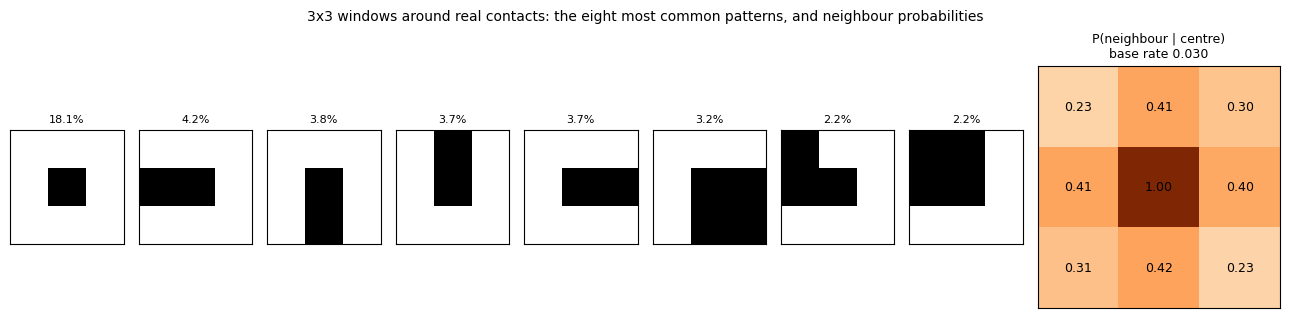

In [3]:
fig = plt.figure(figsize=(13, 3.4))
common = patterns.most_common(8)
for k, (p, n) in enumerate(common):
    ax = fig.add_subplot(1, 10, k + 1)
    ax.imshow(np.array(p).reshape(3, 3), cmap="Greys", vmin=0, vmax=1)
    ax.set_title(f"{n / n_centre:.1%}", fontsize=8); ax.set_xticks([]); ax.set_yticks([])
ax = fig.add_subplot(1, 10, (9, 10))
im = ax.imshow(P, cmap="Oranges", vmin=0, vmax=1)
for (r, c), v in np.ndenumerate(P):
    ax.text(c, r, f"{v:.2f}", ha="center", va="center", fontsize=9)
ax.set_title(f"P(neighbour | centre)\nbase rate {base:.3f}", fontsize=9); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("3x3 windows around real contacts: the eight most common patterns, and neighbour probabilities", fontsize=10)
plt.tight_layout()
plt.savefig(f"{FIGS}/day12-contact-patterns.png", dpi=150, bbox_inches="tight"); plt.show()

Only part of the possible patterns ever occur, and a contact makes its
neighbours far more likely to be contacts too than the base rate
suggests. A predictor that looks at a *neighbourhood* of the contact map,
not one pair at a time, can exploit this. PconsC2 (2014) did it with
random forests over an 11 × 11 window of first-round predictions; deep
residual CNNs (RaptorX-Contact, 2017; AlphaFold 1, 2018) learned it end to
end, which is exactly Day 10's "a contact map is an image".

# Part 2 — AlphaFold2 in practice

## An AlphaFold DB model and its confidence

The AlphaFold Database holds predictions for more than 214 million
proteins. Each model comes with two confidence measures:

- **pLDDT** (0-100, stored in the B-factor column): per residue, how well
  the local structure is predicted to agree with the truth. Above 90 is
  very high, below 50 usually means disorder.
- **PAE** (predicted aligned error, in Å): for every pair of residues,
  the expected position error of residue *j* when the model is aligned on
  residue *i*. Low PAE between two domains means their *relative*
  placement is confident.

AF-P68871-F1 Hemoglobin subunit beta - 147 residues, mean pLDDT 97.2
AlphaFold model vs crystal structure 4HHB chain B: TM-score 0.988, RMSD 0.51 A over the aligned residues


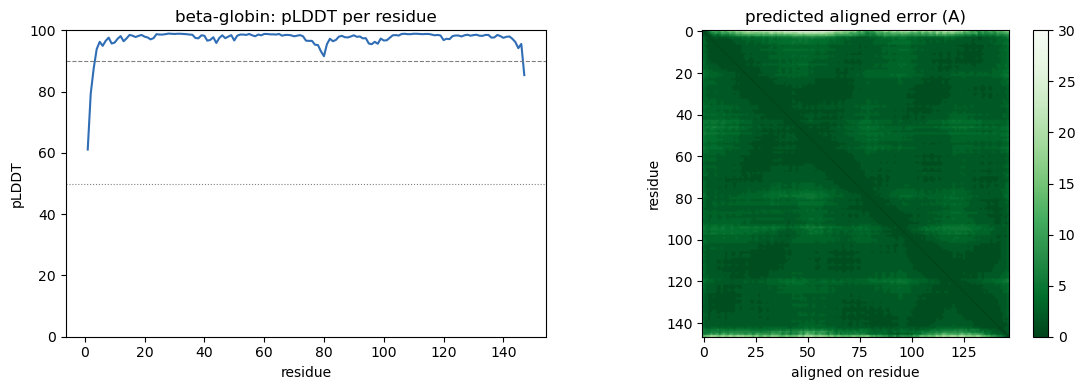

In [4]:
def alphafold_db(accession):
    meta = requests.get(f"https://alphafold.ebi.ac.uk/api/prediction/{accession}", timeout=60).json()[0]
    model = requests.get(meta["pdbUrl"], timeout=60).text
    pae = requests.get(meta["paeDocUrl"], timeout=60).json()
    pae = np.array((pae[0] if isinstance(pae, list) else pae)["predicted_aligned_error"])
    res, seq = chain_residues(model)
    plddt = np.array([r["CA"].get_bfactor() for r in res])
    return meta, res, seq, plddt, pae

meta, af_res, af_seq, af_plddt, af_pae = alphafold_db("P68871")      # human beta-globin
print(meta["entryId"], meta["uniprotDescription"], f"- {len(af_seq)} residues, mean pLDDT {af_plddt.mean():.1f}")

nat_res, nat_seq = chain_residues(pdb_text("4HHB"), "B")
tm = tmtools.tm_align(ca(af_res), ca(nat_res), af_seq, nat_seq)
print(f"AlphaFold model vs crystal structure 4HHB chain B: TM-score {tm.tm_norm_chain2:.3f}, "
      f"RMSD {tm.rmsd:.2f} A over the aligned residues")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(np.arange(1, len(af_plddt) + 1), af_plddt, color="#2f6db5")
a1.axhline(90, ls="--", color="grey", lw=0.8); a1.axhline(50, ls=":", color="grey", lw=0.8)
a1.set_ylim(0, 100); a1.set_xlabel("residue"); a1.set_ylabel("pLDDT"); a1.set_title("beta-globin: pLDDT per residue")
im = a2.imshow(af_pae, cmap="Greens_r", vmin=0, vmax=30)
a2.set_title("predicted aligned error (A)"); a2.set_xlabel("aligned on residue"); a2.set_ylabel("residue")
plt.colorbar(im, ax=a2, fraction=0.046)
plt.tight_layout(); plt.savefig(f"{FIGS}/day12-hbb-plddt-pae.png", dpi=150, bbox_inches="tight"); plt.show()

## Low confidence often means disorder, not failure: p53

The tumour suppressor p53 has a folded DNA-binding domain and long
intrinsically disordered regions. Its N-terminal transactivation domain
only folds into a helix when bound to a partner such as MDM2 (PDB 1YCR),
the "Region IV" example of the lecture.

p53: 393 residues; 30% of residues have pLDDT < 50
  N-terminal region (1-60)       mean pLDDT  47.6
  DNA-binding domain (94-292)    mean pLDDT  95.3
  C-terminal 40 residues         mean pLDDT  45.8


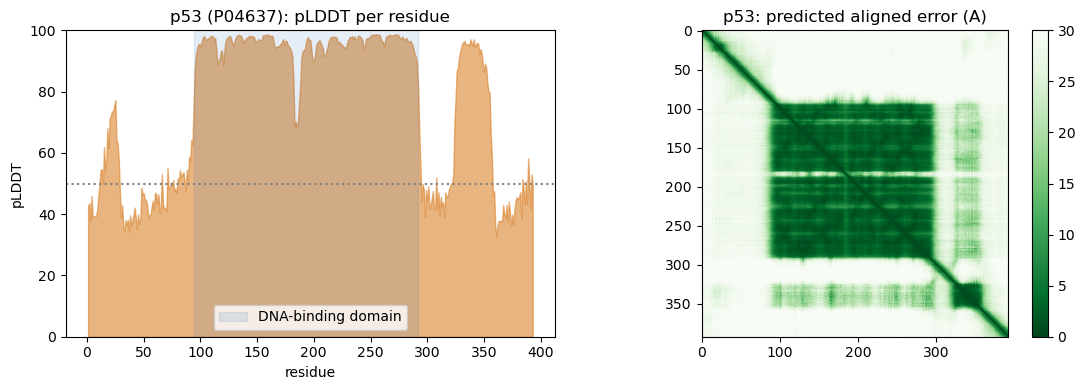

In [5]:
meta53, res53, seq53, plddt53, pae53 = alphafold_db("P04637")
pos = np.arange(1, len(plddt53) + 1)
print(f"p53: {len(seq53)} residues; {np.mean(plddt53 < 50):.0%} of residues have pLDDT < 50")
for name, a, b in [("N-terminal region (1-60)", 1, 60), ("DNA-binding domain (94-292)", 94, 292),
                   ("C-terminal 40 residues", len(seq53) - 39, len(seq53))]:
    print(f"  {name:30s} mean pLDDT {plddt53[a - 1:b].mean():5.1f}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.fill_between(pos, plddt53, color="#d9822b", alpha=0.6)
a1.axvspan(94, 292, color="#2f6db5", alpha=0.12, label="DNA-binding domain")
a1.axhline(50, ls=":", color="grey")
a1.set_ylim(0, 100); a1.set_xlabel("residue"); a1.set_ylabel("pLDDT"); a1.legend(loc="lower center")
a1.set_title("p53 (P04637): pLDDT per residue")
im = a2.imshow(pae53, cmap="Greens_r", vmin=0, vmax=30)
a2.set_title("p53: predicted aligned error (A)"); plt.colorbar(im, ax=a2, fraction=0.046)
plt.tight_layout(); plt.savefig(f"{FIGS}/day12-p53-plddt-pae.png", dpi=150, bbox_inches="tight"); plt.show()

Low pLDDT does not mean AlphaFold has failed. It usually marks regions
with no single structure. The PAE map shows one confident block, the
DNA-binding domain, and no confident relative placement for the rest.

## Structure from a single sequence: ESMFold

AlphaFold2 needs a multiple sequence alignment. ESMFold (Lin et al. 2023)
replaces it with the ESM-2 protein language model of Day 11 and predicts
a structure from one sequence, in seconds, through the public ESM Atlas
API. Here: Ephrin-A5, chain A of PDB 1SHW, the Region I exercise target.

In [6]:
ephrin = ("VADRYAVYWNSSNPRFQRGDYHIDVCINDYLDVFCPHYEDSVPEDKTERYVLYMVNFDGYSACDHTSKGFKRWECNRPHSPNGPLKFSEKFQL"
          "FTPFSLGFEFRPGREYFYISSAIPDNGRRSCLKLKVFVRPTNSCM")
try:
    r = requests.post("https://api.esmatlas.com/foldSequence/v1/pdb/", data=ephrin, timeout=120)
    esm_res, esm_seq = chain_residues(r.text)
    esm_plddt = np.array([x["CA"].get_bfactor() for x in esm_res])
    esm_plddt = esm_plddt * 100 if esm_plddt.max() <= 1 else esm_plddt
    cry_res, cry_seq = chain_residues(pdb_text("1SHW"), "A")
    t = tmtools.tm_align(ca(esm_res), ca(cry_res), esm_seq, cry_seq)
    print(f"ESMFold, single sequence, {len(esm_seq)} residues: mean pLDDT {esm_plddt.mean():.1f}; "
          f"vs crystal 1SHW chain A: TM-score {t.tm_norm_chain2:.3f}, RMSD {t.rmsd:.2f} A")
except Exception as e:
    print("The ESM Atlas API did not answer (it is a free public service):", e)

ESMFold, single sequence, 138 residues: mean pLDDT 86.0; vs crystal 1SHW chain A: TM-score 0.941, RMSD 1.27 A


A TM-score above 0.5 means the same fold; above about 0.9 the two
structures are nearly identical. For a well-studied domain like this,
a single sequence is enough, because the language model has learned the
family. For proteins from small families, and for complexes, alignments
still help (lecture: ESMFold is fast, "accuracy slightly worse for single
proteins, much worse for complexes").

# Part 3 — Generative models: diffusion

AlphaFold3 (2024) no longer builds the structure with AlphaFold2's
structure module. Its diffusion module starts from random atom positions
and removes noise step by step, the same principle as the image
generators behind DALL-E and as RFdiffusion for protein design. Here is
that principle, first on an image, then on points we can train in seconds.

## The forward process: adding noise

In [7]:
mnist = torchvision.datasets.MNIST(root=os.path.join(tempfile.gettempdir(), 'kb8029_mnist'), train=True, download=True)
X_all = mnist.data.float() / 255.0
labels_all = mnist.targets
print('MNIST:', tuple(X_all.shape), 'pixel range', X_all.min().item(), X_all.max().item())

MNIST: (60000, 28, 28) pixel range 0.0 1.0


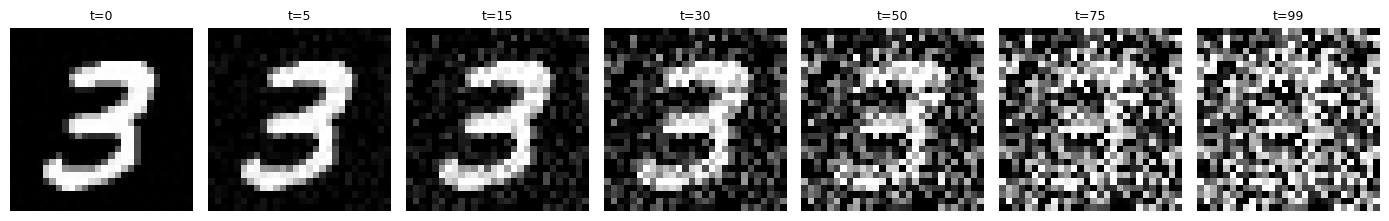

sqrt(1 - alpha_bar) at t=0: 0.0100, at t=50: 0.6926, at t=99: 0.9601


In [8]:
T = 100
betas = torch.linspace(1e-4, 0.05, T)
alphas = 1 - betas
alpha_bars = torch.cumprod(alphas, dim=0)   # alpha_bar_t = prod_{s<=t} alpha_s

img = (X_all[7] * 2 - 1)   # a real digit, rescaled to [-1, 1]
steps_to_show = [0, 5, 15, 30, 50, 75, 99]

torch.manual_seed(1)
noise = torch.randn_like(img)
fig, axes = plt.subplots(1, len(steps_to_show), figsize=(14, 2.2))
for ax, t in zip(axes, steps_to_show):
    ab = alpha_bars[t]
    xt = torch.sqrt(ab) * img + torch.sqrt(1 - ab) * noise
    ax.imshow(((xt.clamp(-1, 1) + 1) / 2), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f't={t}', fontsize=9); ax.axis('off')
plt.tight_layout()
plt.savefig(f'{FIGS}/day12-forward-noising.png', dpi=120)
plt.show()

print(f'sqrt(1 - alpha_bar) at t=0: {torch.sqrt(1-alpha_bars[0]):.4f}, '
      f'at t=50: {torch.sqrt(1-alpha_bars[50]):.4f}, '
      f'at t=99: {torch.sqrt(1-alpha_bars[99]):.4f}')

By the last step essentially nothing of the digit is left. A diffusion
model is trained to undo *one* small step at a time: given a noisy input
and the step number, predict the noise that was added.

## A diffusion model that generates something: points on a ring

Training an image generator needs far more compute than a notebook has.
A 2D toy problem shows the whole mechanism in seconds: real data are
points on a noisy ring; the network learns to predict the added noise; the
reverse process then starts from pure Gaussian noise.

In [9]:
def make_ring_data(n):
    theta = torch.rand(n) * 2 * np.pi
    r = 3 + 0.3 * torch.randn(n)
    return torch.stack([r * torch.cos(theta), r * torch.sin(theta)], dim=1)


X2d = make_ring_data(4000).to(device)

T2 = 100
betas2 = torch.linspace(1e-4, 0.05, T2).to(device)
alphas2 = 1 - betas2
alpha_bars2 = torch.cumprod(alphas2, dim=0)


class DenoiseNet(nn.Module):
    def __init__(self, dim=2, hidden=128):
        super().__init__()
        self.time_embed = nn.Embedding(T2, hidden)
        self.net = nn.Sequential(nn.Linear(dim + hidden, hidden), nn.ReLU(),
                                  nn.Linear(hidden, hidden), nn.ReLU(),
                                  nn.Linear(hidden, dim))

    def forward(self, x, t):
        return self.net(torch.cat([x, self.time_embed(t)], dim=1))


dnet = DenoiseNet().to(device)
opt2 = torch.optim.Adam(dnet.parameters(), lr=2e-3)

diff_losses = []
for step in range(2000):
    idx = torch.randint(0, X2d.size(0), (256,), device=device)
    x0 = X2d[idx]
    t = torch.randint(0, T2, (x0.size(0),), device=device)
    noise = torch.randn_like(x0)
    ab = alpha_bars2[t].unsqueeze(1)
    xt = torch.sqrt(ab) * x0 + torch.sqrt(1 - ab) * noise
    pred_noise = dnet(xt, t)
    loss = F.mse_loss(pred_noise, noise)
    opt2.zero_grad(); loss.backward(); opt2.step()
    diff_losses.append(loss.item())

print(f'noise-prediction MSE: step 1 = {diff_losses[0]:.3f}, step 2000 = {np.mean(diff_losses[-100:]):.3f}')

noise-prediction MSE: step 1 = 0.939, step 2000 = 0.638


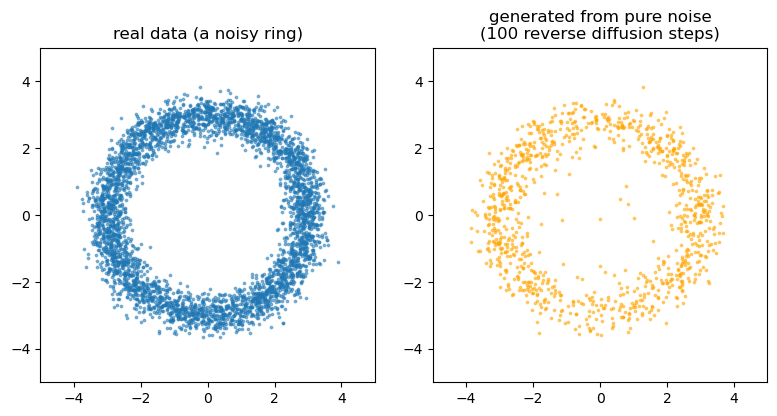

real data      mean/std: [-0.006  0.049] [2.145 2.114]
generated data mean/std: [-0.14   0.066] [2.227 1.921]


In [10]:
@torch.no_grad()
def reverse_sample(n=1000):
    x = torch.randn(n, 2, device=device)
    for t in reversed(range(T2)):
        tt = torch.full((n,), t, device=device, dtype=torch.long)
        pred_noise = dnet(x, tt)
        alpha, alpha_bar, beta = alphas2[t], alpha_bars2[t], betas2[t]
        noise = torch.randn_like(x) if t > 0 else torch.zeros_like(x)
        x = (1 / torch.sqrt(alpha)) * (x - (beta / torch.sqrt(1 - alpha_bar)) * pred_noise) + torch.sqrt(beta) * noise
    return x


generated = reverse_sample(1000).cpu().numpy()
real = X2d.cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].scatter(real[:, 0], real[:, 1], s=3, alpha=0.5)
axes[0].set_title('real data (a noisy ring)')
axes[1].scatter(generated[:, 0], generated[:, 1], s=3, alpha=0.5, color='orange')
axes[1].set_title('generated from pure noise\n(100 reverse diffusion steps)')
for ax in axes:
    ax.set_xlim(-5, 5); ax.set_ylim(-5, 5); ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(f'{FIGS}/day12-toy-diffusion.png', dpi=120)
plt.show()

print('real data      mean/std:', real.mean(0).round(3), real.std(0).round(3))
print('generated data mean/std:', generated.mean(0).round(3), generated.std(0).round(3))

From pure noise, 100 learned denoising steps recover the ring. Replace the
2D points by the 3D coordinates of every atom in a complex, condition the
denoiser on the sequence (through AlphaFold3's Pairformer representation),
and you have AlphaFold3's diffusion module. Train it to generate new
backbones instead, and you have RFdiffusion; a second network
(ProteinMPNN) then designs a sequence for the generated backbone.

## Try it yourself

- In Part 1, add a few all-β proteins (e.g. 1TTG, 1FNA). Do new patterns
  appear, or do the same ones dominate?
- In Part 2, look up a protein you know in the AlphaFold DB (any UniProt
  accession) and interpret its pLDDT and PAE.
- In Part 3, train the denoiser on only 20 ring points instead of 4,000.
  Do the generated points still form a ring, or do they cluster around the
  training points? (The lecture's "memorisation" question in miniature.)